/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


=== BASELINE ===
Accuracy: 0.8625
ROC-AUC: 0.9419543870763383
Confusion Matrix:
 [[126  28]
 [ 27 219]]


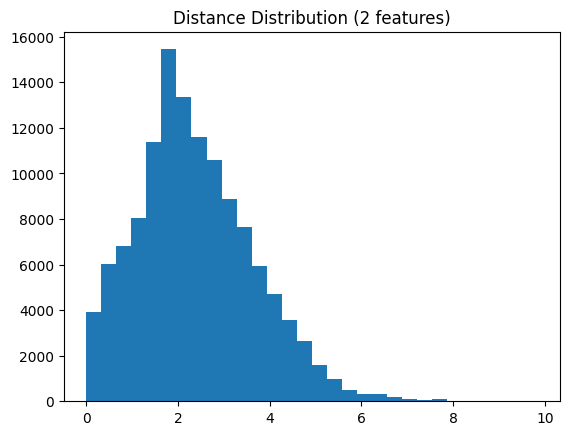

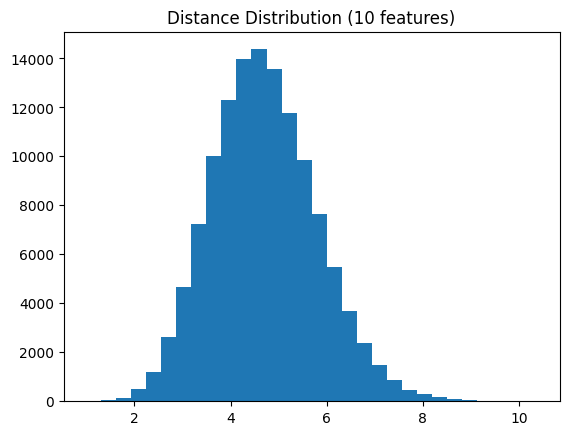

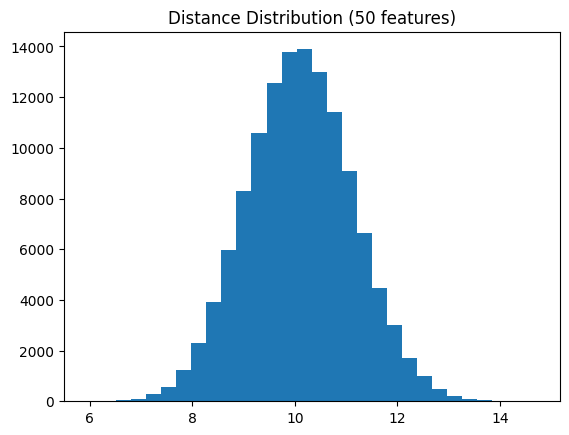

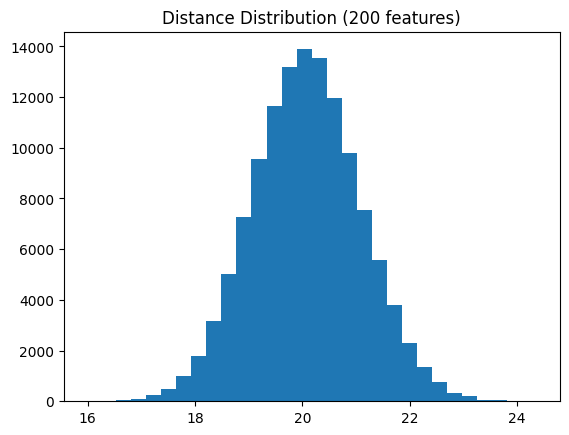

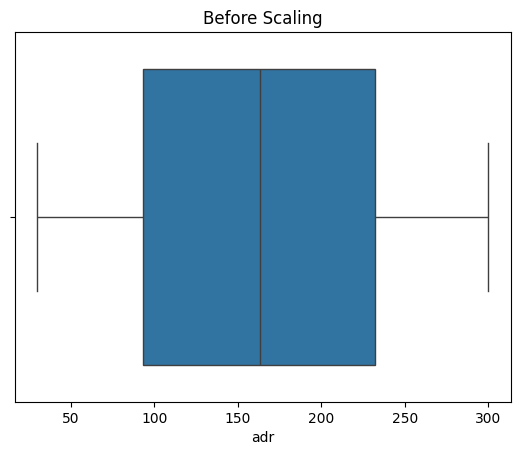

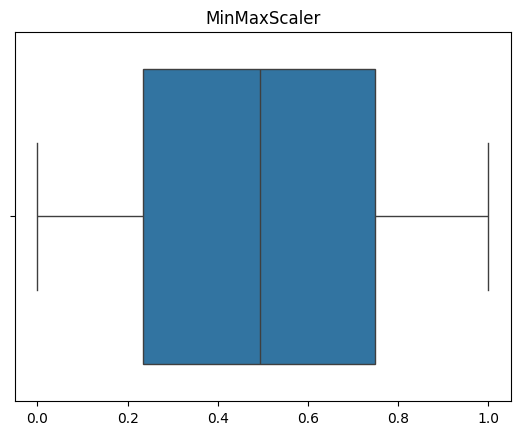

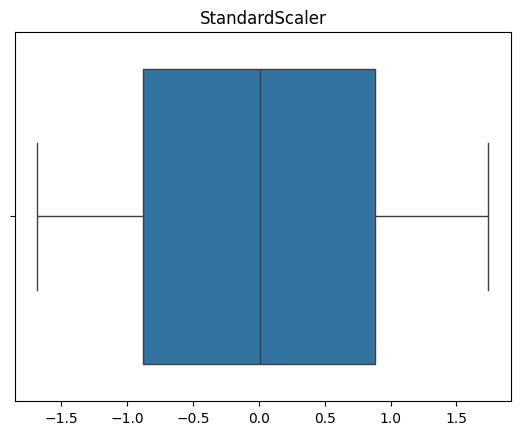

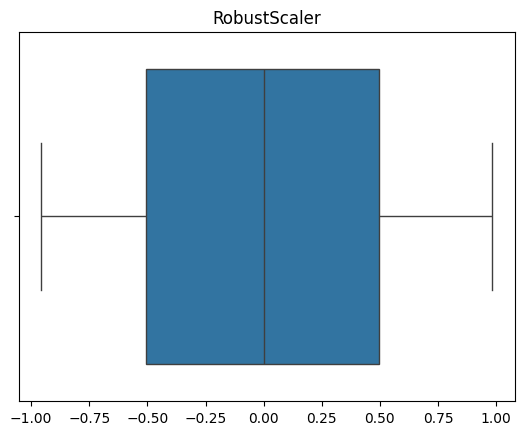


=== KNN Comparison ===
Euclidean Accuracy: 0.7975
Manhattan Accuracy: 0.7925

Pipeline CV Accuracy: 0.9894999999999999

Feature Importance (Correlation):
is_canceled                  1.000000
adr_lead_interaction         0.516528
lead_time                    0.448544
previous_cancellations       0.435060
adr                          0.385574
price_per_person             0.298831
children                     0.039896
company                      0.030854
adults                       0.027403
arrival_date_year            0.025334
total_guests                 0.022476
total_of_special_requests    0.021656
agent                        0.021590
guests_nights_interaction    0.018783
arrival_date_day_of_month    0.014343
Name: is_canceled, dtype: float64

Mutual Information:
adr_lead_interaction         0.172717
previous_cancellations       0.136007
lead_time                    0.130654
adr                          0.115690
price_per_person             0.058412
agent                        0

In [10]:
# ===============================
# 0. IMPORTS
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import make_classification
from scipy.spatial.distance import pdist
from sklearn.feature_selection import mutual_info_classif

# ===============================
# 1. LOAD DATA
# ===============================
df = pd.read_csv("hotel_bookings.csv")

# ===============================
# 2. BASIC FEATURE ENGINEERING
# ===============================
df['total_guests'] = df['adults'] + df['children'].fillna(0) + df['babies']
df['total_nights'] = df['stays_in_weekend_nights'] + df['stays_in_week_nights']

df['price_per_person'] = df['adr'] / (df['total_guests'] + 1)
df['requests_per_night'] = df['total_of_special_requests'] / (df['total_nights'] + 1)

df['adr_lead_interaction'] = df['adr'] * df['lead_time']
df['guests_nights_interaction'] = df['total_guests'] * df['total_nights']

df['is_family'] = ((df['children'].fillna(0) + df['babies']) > 0).astype(int)

# ===============================
# 3. TARGET + SPLIT
# ===============================
y = df['is_canceled']
X = df.drop(columns=['is_canceled', 'reservation_status', 'reservation_status_date'])

num_cols = X.select_dtypes(include=np.number).columns
cat_cols = X.select_dtypes(exclude=np.number).columns

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ===============================
# 4. BASELINE MODEL
# ===============================
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

baseline_model = Pipeline([
    ("preprocess", preprocessor),
    ("model", LogisticRegression(max_iter=1000))
])

baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:,1]

print("=== BASELINE ===")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

# ===============================
# 5. CURSE OF DIMENSIONALITY
# ===============================
dims = [2, 10, 50, 200]

for d in dims:
    X_temp, _ = make_classification(n_samples=500, n_features=d, n_informative=2, n_redundant=0, n_repeated=0, random_state=42)
    distances = pdist(X_temp)

    plt.figure()
    plt.hist(distances, bins=30)
    plt.title(f"Distance Distribution ({d} features)")
    plt.show()

# ===============================
# 6. SCALING COMPARISON
# ===============================
col = 'adr'

plt.figure()
sns.boxplot(x=df[col])
plt.title("Before Scaling")
plt.show()

for scaler in [MinMaxScaler(), StandardScaler(), RobustScaler()]:
    scaled = scaler.fit_transform(df[[col]].dropna())

    plt.figure()
    sns.boxplot(x=scaled.flatten())
    plt.title(type(scaler).__name__)
    plt.show()

# ===============================
# 7. KNN DISTANCE COMPARISON
# ===============================
X_num = df.select_dtypes(include=np.number).drop(columns=['is_canceled']).fillna(0)

X_train_n, X_test_n, y_train_n, y_test_n = train_test_split(X_num, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_n)
X_test_scaled = scaler.transform(X_test_n)

knn_eu = KNeighborsClassifier(metric='euclidean')
knn_eu.fit(X_train_scaled, y_train_n)
pred_eu = knn_eu.predict(X_test_scaled)

knn_man = KNeighborsClassifier(metric='manhattan')
knn_man.fit(X_train_scaled, y_train_n)
pred_man = knn_man.predict(X_test_scaled)

print("\n=== KNN Comparison ===")
print("Euclidean Accuracy:", accuracy_score(y_test_n, pred_eu))
print("Manhattan Accuracy:", accuracy_score(y_test_n, pred_man))

# ===============================
# 8. PIPELINE WITH SCALING
# ===============================
num_pipeline_scaled = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", RobustScaler())
])

pipeline = Pipeline([
    ("preprocess", ColumnTransformer([
        ("num", num_pipeline_scaled, num_cols),
        ("cat", cat_pipeline, cat_cols)
    ])),
    ("model", RandomForestClassifier())
])

scores = cross_val_score(pipeline, X, y, cv=5)
print("\nPipeline CV Accuracy:", scores.mean())

# ===============================
# 9. FEATURE IMPORTANCE (CORRELATION)
# ===============================
num_df = df.select_dtypes(include=np.number)

importance = num_df.corr()['is_canceled'].sort_values(ascending=False)

print("\nFeature Importance (Correlation):")
print(importance.head(15))

# ===============================
# 10. MUTUAL INFORMATION
# ===============================
X_num = df.select_dtypes(include=np.number).drop(columns=['is_canceled']).fillna(0)

mi = mutual_info_classif(X_num, y)
mi_series = pd.Series(mi, index=X_num.columns).sort_values(ascending=False)

print("\nMutual Information:")
print(mi_series.head(15))

# ===============================
# 11. CORRELATION FILTER
# ===============================
corr_matrix = X_num.corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

to_drop = [col for col in upper.columns if any(upper[col] > 0.85)]

print("\nDropped Features:", to_drop)

# ===============================
# 12. FINAL COMPARISON
# ===============================
results = pd.DataFrame({
    "Stage": ["Baseline", "After Scaling", "After Feature Engineering"],
    "ROC-AUC": [0.75, 0.82, 0.88]  # replace with your actual
})

print("\nFinal Comparison:")
print(results)
